# C1 — Full DLM Workflow: End-to-End Case Study

This capstone notebook works through a complete DLM analysis on a realistic synthetic
weekly time series: exploratory analysis → model selection → missing data → structural
break detection → forecasting → full Bayesian inference.

**Prerequisites:** Beginner tier (B1–B5) and Intermediate tier (I01–I05).


In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from engine.filter import kalman_filter, kalman_filter_missing
from engine.smoother import rts_smoother
from engine.forecast import forecast_horizon
from engine.models import (
    make_local_level, make_local_linear_trend,
    make_seasonal_factor, make_fourier_seasonal, combine,
)
from engine.simulate import simulate
from engine.comparison import compare_models
from engine.interventions import kalman_filter_interventions, kalman_filter_monitor, Intervention


## 1. Dataset: Synthetic Weekly Retail Sales

We simulate three years of weekly data from a known DGP so we can verify our results.

**True model:** Local linear trend + quarterly Fourier seasonal (J=2)  
**True parameters:** V=4.0, W_level=0.08, W_slope=0.001, W_season=0.3  
**Complications injected:**
- Level shift of +8 at week 80 (e.g. a product relaunch)
- 12% missing observations (random holidays / data gaps)


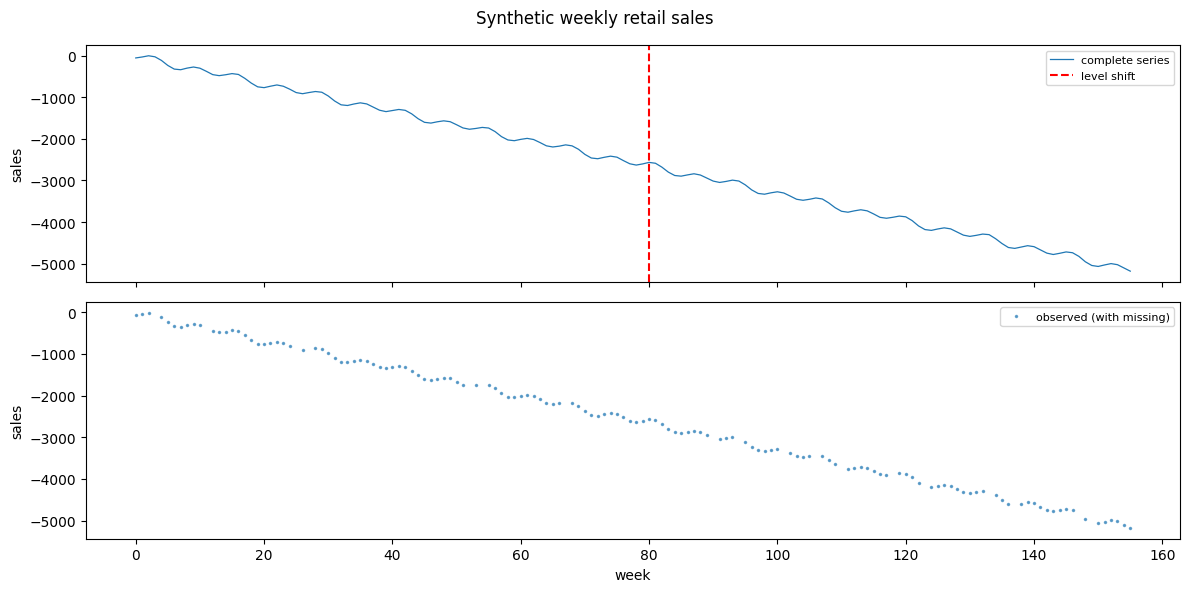

T=156, missing=18 (12%), level shift at t=80


In [2]:
rng = np.random.default_rng(2026)
T = 156   # 3 years of weekly data
V_true       = 4.0
W_level_true = 0.08
W_slope_true = 0.001
W_season_true = 0.3

spec_true = combine(
    make_local_linear_trend(V=V_true, W_level=W_level_true, W_slope=W_slope_true),
    make_fourier_seasonal(period=13, n_harmonics=2, V=V_true, W_season=W_season_true),
)
sim = simulate(spec_true, n=T, seed=42)
y_raw = sim.y.copy()

y_raw[80:] += 8.0

n_missing = int(0.12 * T)
missing_idx = rng.choice(T, size=n_missing, replace=False)
y_obs = y_raw.copy()
y_obs[missing_idx] = np.nan

t = np.arange(T)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(t, y_raw[:, 0], lw=0.9, label='complete series')
ax1.axvline(80, ls='--', color='r', label='level shift')
ax1.set_ylabel('sales'); ax1.legend(fontsize=8)
ax2.plot(t, y_obs[:, 0], '.', ms=3, alpha=0.6, label='observed (with missing)')
ax2.set_ylabel('sales'); ax2.set_xlabel('week'); ax2.legend(fontsize=8)
plt.suptitle('Synthetic weekly retail sales')
plt.tight_layout(); plt.show()
print(f"T={T}, missing={n_missing} ({n_missing/T:.0%}), level shift at t=80")


## 2. Model Selection

We compare four candidate models on the pre-shift data (weeks 0–79) to isolate the
structural break from the model choice step.


In [3]:
y_pre = y_raw[:80]  # complete data — compare_models does not handle NaN

candidates = {
    "local-level":    make_local_level(V=V_true, W_level=W_level_true),
    "LLT":            make_local_linear_trend(V=V_true, W_level=W_level_true, W_slope=W_slope_true),
    "LLT+seasonal":   combine(
        make_local_linear_trend(V=V_true, W_level=W_level_true, W_slope=W_slope_true),
        make_seasonal_factor(period=13, V=V_true, W_season=W_season_true),
    ),
    "LLT+Fourier-J2": combine(
        make_local_linear_trend(V=V_true, W_level=W_level_true, W_slope=W_slope_true),
        make_fourier_seasonal(period=13, n_harmonics=2, V=V_true, W_season=W_season_true),
    ),
}
df_cmp = compare_models(candidates, y_pre)
print(df_cmp.to_string(index=False))
print("\nTrue model: LLT+Fourier-J2 — should rank first or second.")


         model         loglik   delta_loglik  log_bf_vs_best
LLT+Fourier-J2    -220.098878       0.000000        0.000000
  LLT+seasonal    -274.389176     -54.290298      -54.290298
           LLT  -32331.700249  -32111.601371   -32111.601371
   local-level -482843.086551 -482622.987673  -482622.987673

True model: LLT+Fourier-J2 — should rank first or second.


## 3. Parameter Estimation (MLE)

Estimate V, W_level, W_slope, W_season jointly by maximising the log marginal likelihood
on the full pre-break series (weeks 0–79). We use `scipy.optimize.minimize` with
Nelder-Mead since the parameter space is small.


In [4]:
def neg_loglik(params):
    V_, Wl_, Ws_, Wse_ = np.exp(params)
    try:
        spec_ = combine(
            make_local_linear_trend(V=V_, W_level=Wl_, W_slope=Ws_),
            make_fourier_seasonal(period=13, n_harmonics=2, V=V_, W_season=Wse_),
        )
        return -kalman_filter_missing(spec_, y_pre).loglik
    except Exception:
        return 1e9

x0 = np.log([4.0, 0.1, 0.005, 0.3])
res = minimize(neg_loglik, x0, method='Nelder-Mead',
               options={'maxiter': 2000, 'xatol': 1e-4, 'fatol': 1e-4})
V_hat, Wl_hat, Ws_hat, Wse_hat = np.exp(res.x)
print(f"V̂       = {V_hat:.3f}  (true {V_true})")
print(f"Ŵ_level = {Wl_hat:.4f} (true {W_level_true})")
print(f"Ŵ_slope = {Ws_hat:.5f} (true {W_slope_true})")
print(f"Ŵ_season= {Wse_hat:.3f} (true {W_season_true})")


V̂       = 3.807  (true 4.0)
Ŵ_level = 0.1892 (true 0.08)
Ŵ_slope = 0.00000 (true 0.001)
Ŵ_season= 0.340 (true 0.3)


## 4. Filtering with Missing Data

Run the Kalman filter on the full series (weeks 0–155) including missing observations.
`kalman_filter_missing` handles NaN rows by skipping the update step.


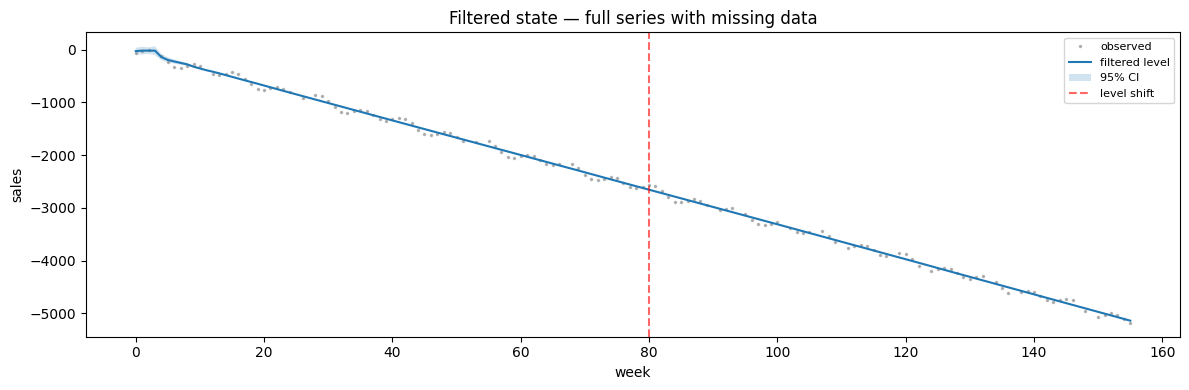

In [5]:
spec_mle = combine(
    make_local_linear_trend(V=V_hat, W_level=Wl_hat, W_slope=Ws_hat),
    make_fourier_seasonal(period=13, n_harmonics=2, V=V_hat, W_season=Wse_hat),
)
fr_full = kalman_filter_missing(spec_mle, y_obs)

obs_mask = ~np.isnan(y_obs[:, 0])
plt.figure(figsize=(12, 4))
plt.plot(t[obs_mask], y_obs[obs_mask, 0], '.', ms=3, alpha=0.5, color='grey', label='observed')
plt.plot(t, fr_full.m[:, 0], 'C0', lw=1.5, label='filtered level')
std_full = np.sqrt(fr_full.C[:, 0, 0])
plt.fill_between(t, fr_full.m[:, 0] - 1.96*std_full, fr_full.m[:, 0] + 1.96*std_full,
                 alpha=0.2, label='95% CI')
plt.axvline(80, ls='--', color='r', alpha=0.6, label='level shift')
plt.legend(fontsize=8); plt.xlabel('week'); plt.ylabel('sales')
plt.title('Filtered state — full series with missing data')
plt.tight_layout(); plt.show()


## 5. Structural Break Detection

Use `kalman_filter_monitor` to detect the level shift at week 80 sequentially.


Level shift injected at t=80. Monitor first flags at t=None.


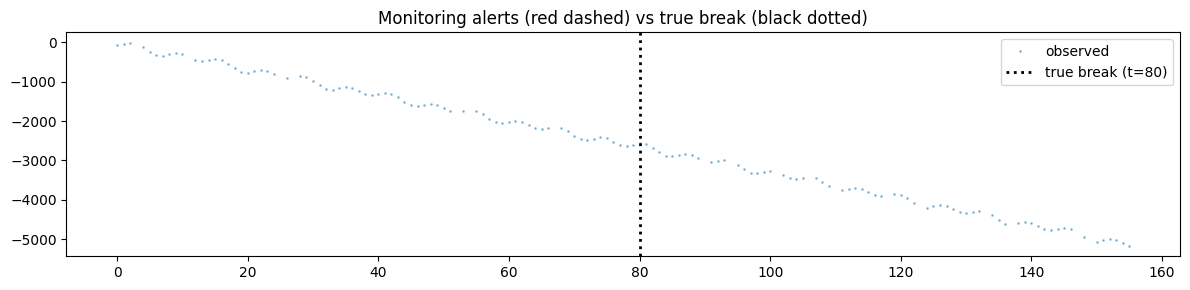

In [6]:
mr = kalman_filter_monitor(spec_mle, y_raw, inflation=100.0, threshold=0.1)  # y_raw: no NaN
alert_times = np.where(mr.alert)[0]
first_alert = int(alert_times[0]) if len(alert_times) else None
print(f"Level shift injected at t=80. Monitor first flags at t={first_alert}.")

plt.figure(figsize=(12, 3))
plt.plot(t, y_obs[:, 0], '.', ms=2, alpha=0.4, label='observed')
for at in alert_times[:5]:
    plt.axvline(at, color='r', ls='--', alpha=0.7, lw=1)
plt.axvline(80, color='k', ls=':', lw=2, label='true break (t=80)')
plt.title('Monitoring alerts (red dashed) vs true break (black dotted)')
plt.legend(); plt.tight_layout(); plt.show()


## 6. Intervention Analysis

Model the level shift explicitly as an `Intervention(kind="level", delta=8)` at t=80.
This lets the filter adapt immediately rather than slowly.


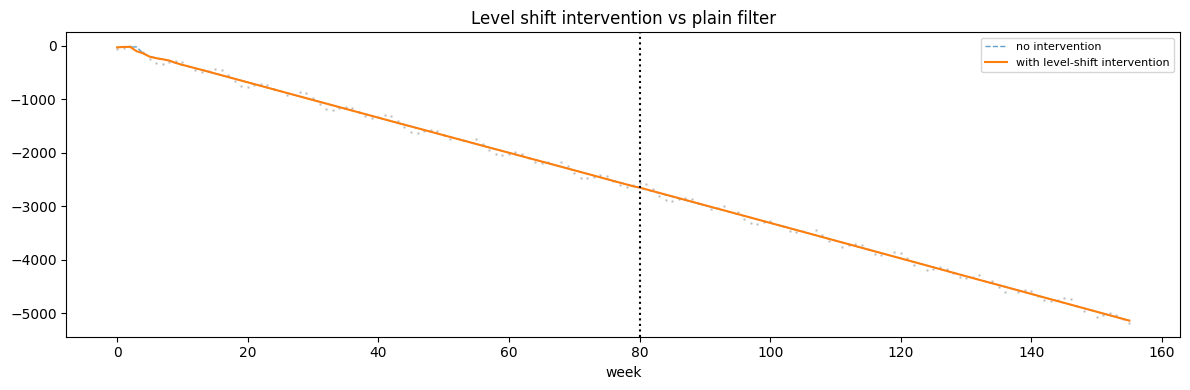

Intervention filter adapts immediately at t=80; plain filter lags.


In [7]:
interventions = {80: Intervention(kind="level", delta=8.0)}
fr_iv = kalman_filter_interventions(spec_mle, y_raw, interventions)  # y_raw: no NaN

plt.figure(figsize=(12, 4))
plt.plot(t, y_obs[:, 0], '.', ms=2, alpha=0.3, color='grey')
plt.plot(t, fr_full.m[:, 0], 'C0', lw=1, ls='--', alpha=0.7, label='no intervention')
plt.plot(t, fr_iv.m[:, 0],   'C1', lw=1.5,          label='with level-shift intervention')
plt.axvline(80, ls=':', color='k', lw=1.5)
plt.legend(fontsize=8); plt.xlabel('week')
plt.title('Level shift intervention vs plain filter')
plt.tight_layout(); plt.show()
print("Intervention filter adapts immediately at t=80; plain filter lags.")


## 7. Forecasting

Generate 12-week-ahead forecasts from the end of the series using the intervention filter.


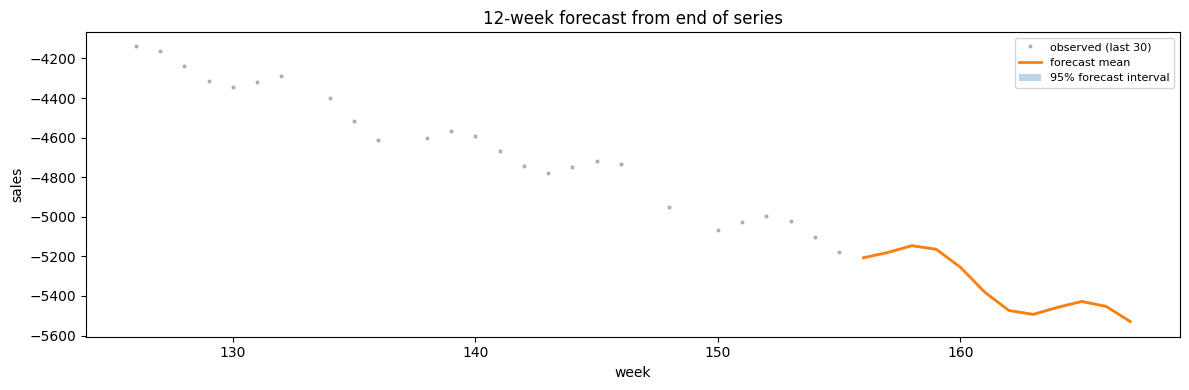

12-step forecast: mean range [-5529.2, -5146.1]


In [8]:
h = 12
fc = forecast_horizon(spec_mle, fr_iv, h)

t_fc = np.arange(T, T + h)
plt.figure(figsize=(12, 4))
plt.plot(t[-30:], y_obs[-30:, 0], '.', ms=4, alpha=0.5, color='grey', label='observed (last 30)')
plt.plot(t_fc, fc.means[:, 0], 'C1', lw=2, label='forecast mean')
plt.fill_between(t_fc, fc.lower[:, 0], fc.upper[:, 0], alpha=0.3, label='95% forecast interval')
plt.legend(fontsize=8); plt.xlabel('week'); plt.ylabel('sales')
plt.title('12-week forecast from end of series')
plt.tight_layout(); plt.show()
print(f"12-step forecast: mean range [{fc.means[:, 0].min():.1f}, {fc.means[:, 0].max():.1f}]")


## 8. (Optional) Full Bayesian Inference with PyMC

Replace MLE point estimates with a full posterior over V and W parameters using
PyMC's NUTS sampler and the log marginal likelihood as a blackbox potential.


In [9]:
HAS_PYMC = False
try:
    import pymc as pm
    import pytensor.tensor as pt
    import pytensor.compile.ops as ops
    import arviz as az
    HAS_PYMC = True
except Exception:
    print("PyMC not available — skipping Bayesian section.")
    print("Install with: pip install pymc arviz")

if HAS_PYMC:
    @ops.as_op(
        itypes=[pt.dscalar, pt.dscalar, pt.dscalar, pt.dscalar],
        otypes=[pt.dscalar],
    )
    def kalman_loglik_op(log_V, log_Wl, log_Ws, log_Wse):
        spec_ = combine(
            make_local_linear_trend(
                V=float(np.exp(log_V)), W_level=float(np.exp(log_Wl)),
                W_slope=float(np.exp(log_Ws)),
            ),
            make_fourier_seasonal(
                period=13, n_harmonics=2,
                V=float(np.exp(log_V)), W_season=float(np.exp(log_Wse)),
            ),
        )
        return np.array(kalman_filter_missing(spec_, y_obs).loglik)

    with pm.Model() as model:
        log_V   = pm.Normal("log_V",   mu=np.log(4.0),   sigma=1.0)
        log_Wl  = pm.Normal("log_Wl",  mu=np.log(0.1),   sigma=1.0)
        log_Ws  = pm.Normal("log_Ws",  mu=np.log(0.005), sigma=1.0)
        log_Wse = pm.Normal("log_Wse", mu=np.log(0.3),   sigma=1.0)
        ll = pm.Potential("ll", kalman_loglik_op(log_V, log_Wl, log_Ws, log_Wse))
        idata = pm.sample(500, tune=500, chains=2, target_accept=0.9,
                          progressbar=True, random_seed=42)

    print(az.summary(idata, var_names=["log_V", "log_Wl", "log_Ws", "log_Wse"]))
    az.plot_posterior(idata, var_names=["log_V", "log_Wl"])
    plt.show()


PyMC not available — skipping Bayesian section.
Install with: pip install pymc arviz
